# mechanism_viewer real-world examples

## Cancer dataset

This notebook evaluates the package’s practicability in real‑world scenarios by applying it to an external dataset. The dataset used in this example is the Breast Cancer Wisconsin Data Set, where the main objective was to predict whether the cancer is benign or malignant.

Additionally, the features of this dataset are characteristics of the cell nuclei present in a digitalized image of a fine needle aspirate (FNA) of a breast mass.

To support this analysis, the goal of `mechanism_viewer` is to examine whether the missing values are consistent with `MCAR`, `MAR`, `MNAR`, or a mixed missingness pattern.

>Note: `mechanism_viewer` is an exploratory package, and interpretations of its results should always be made with caution.

### 1. Load the dataset

In [1]:
import pandas as pd

df = pd.read_csv("../sample_data/cancer/data.csv")
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


This dataset has a lot of columns, 33 in fact, so the analysis must be done carefully to avoid missing any important missingness patterns.

In addition, the dataset contains a mix of continuous and categorical variables, being the target column, `diagnosis`, the only categorical feature.

### 2. Removing columns

For the missingness analysis, the identifiers will be removed, which in this case is the `id` column.

Furthermore, the raw dataset has a column called `Unnamed: 32`. In this file it is completely empty, so it should not be interpreted as a real feature. Thus it can be removed.

In [2]:
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

### 3. Explore the dataset

The code below gives a quick view of the observed distributions. Continuous variables are shown as histograms, while categorical variables are shown as bar charts.

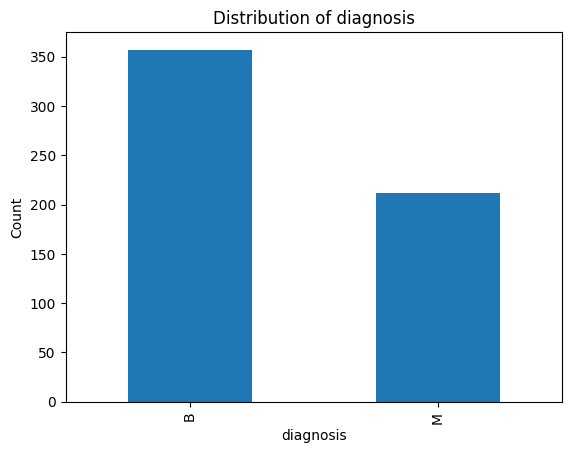

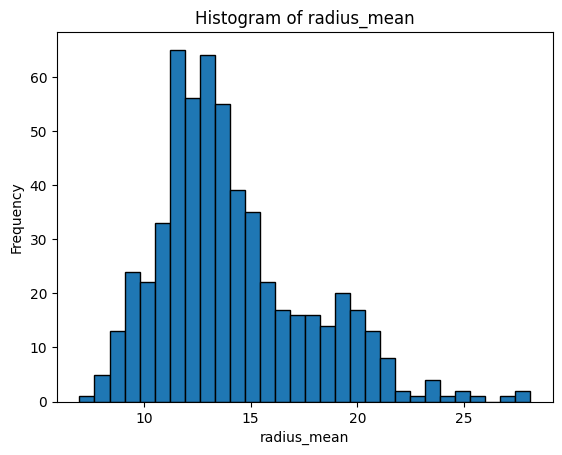

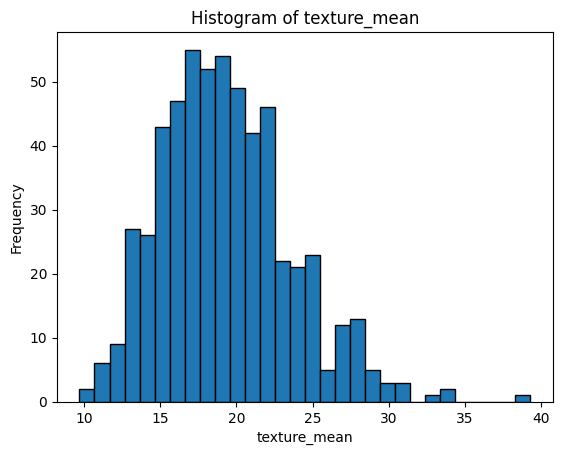

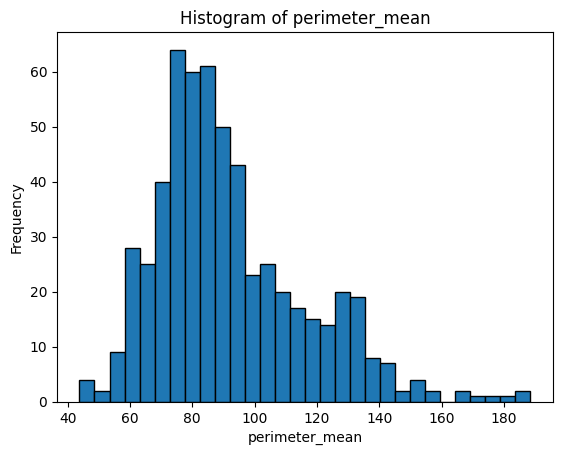

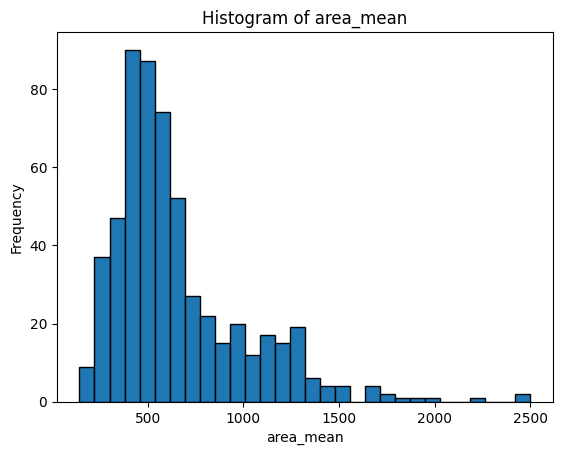

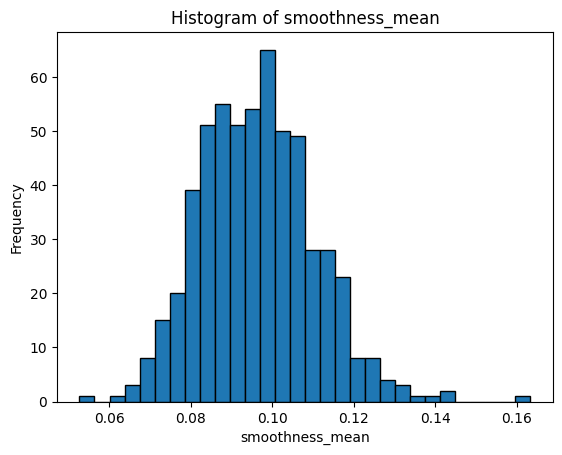

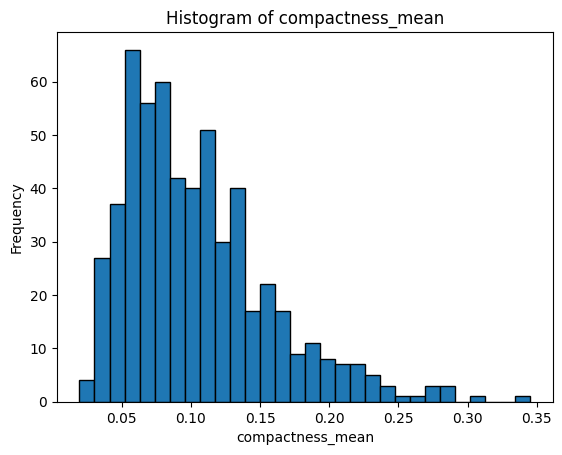

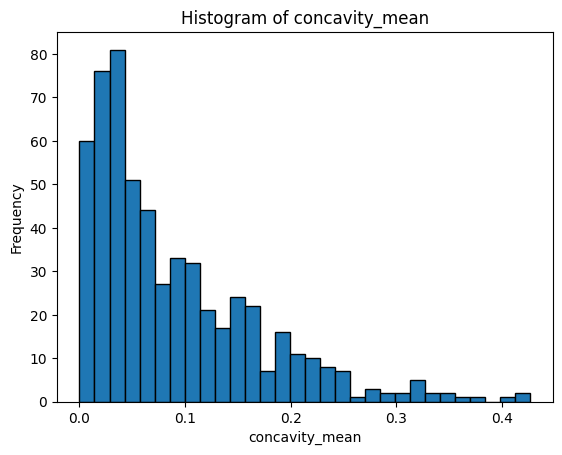

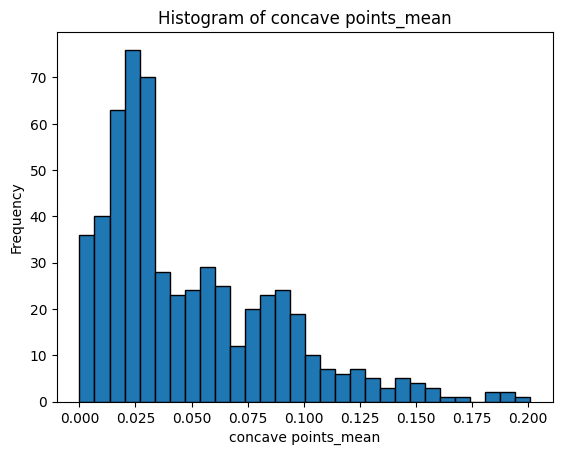

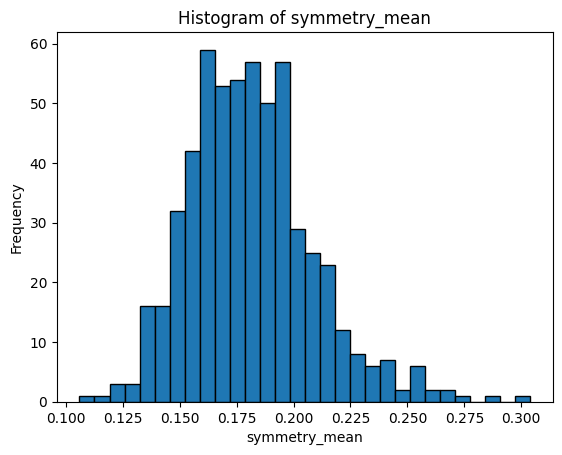

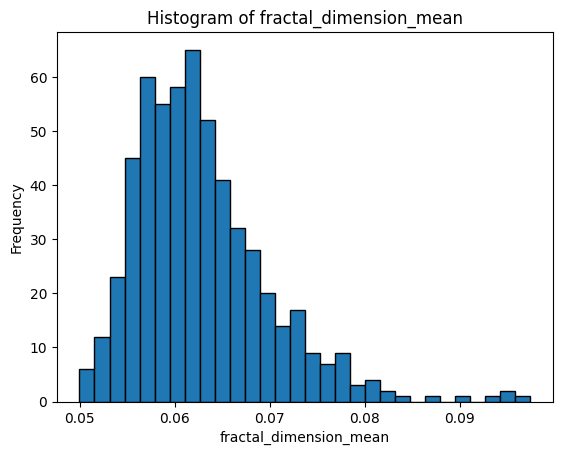

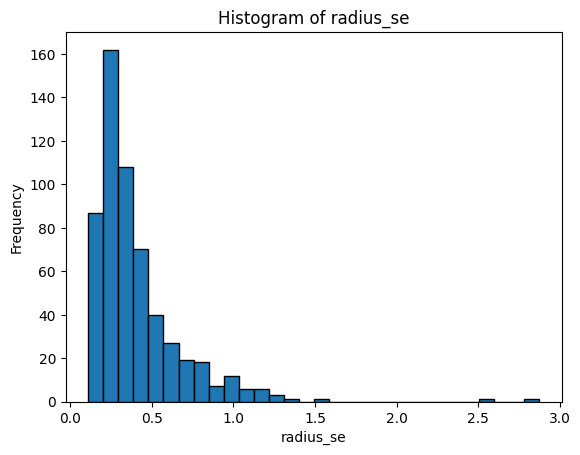

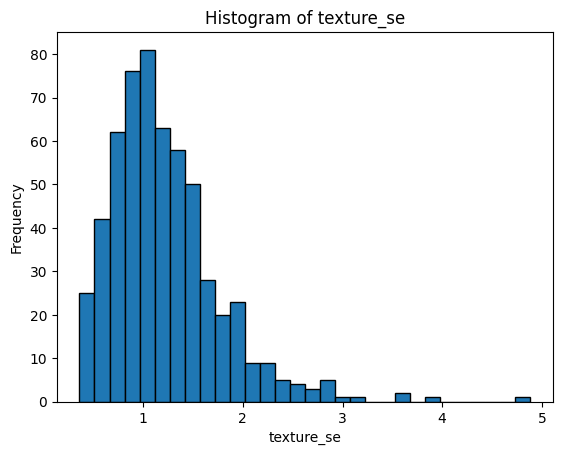

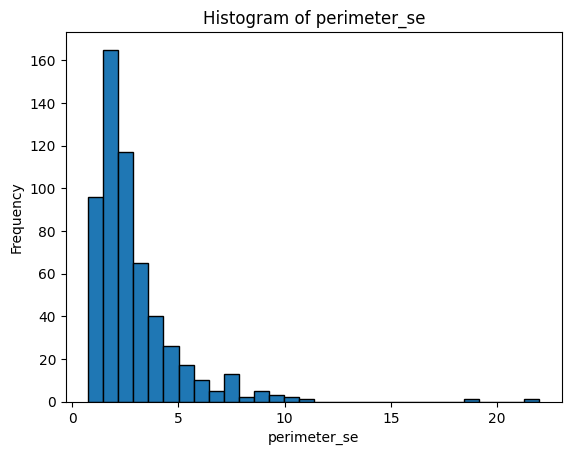

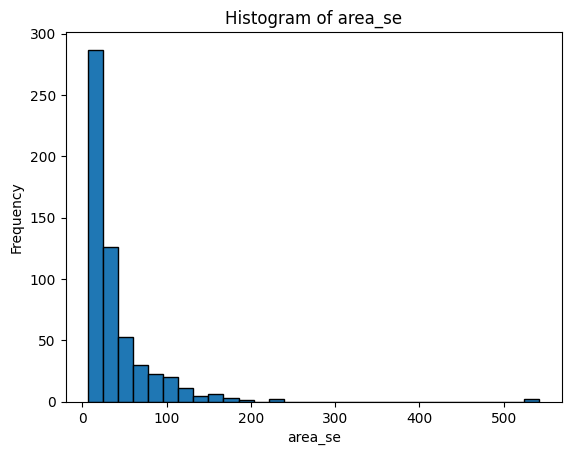

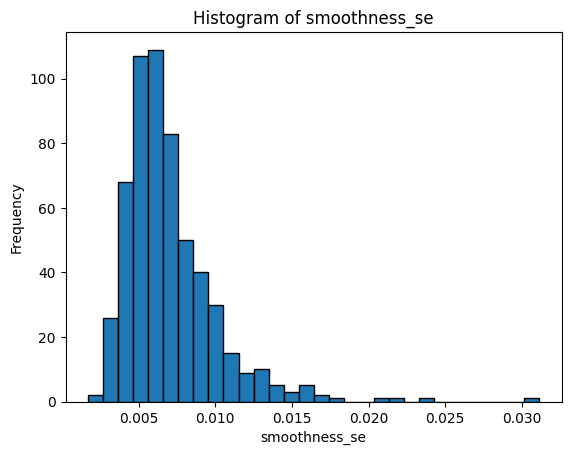

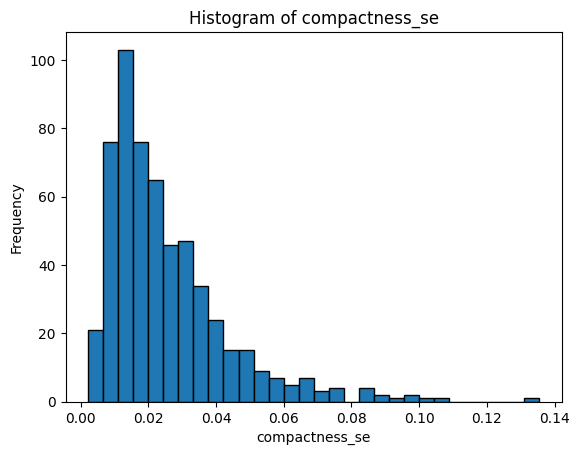

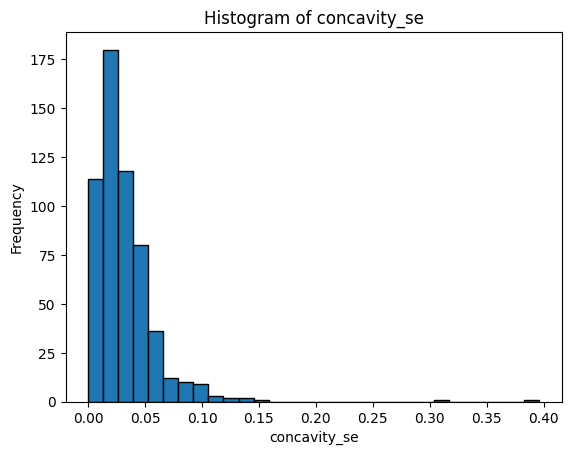

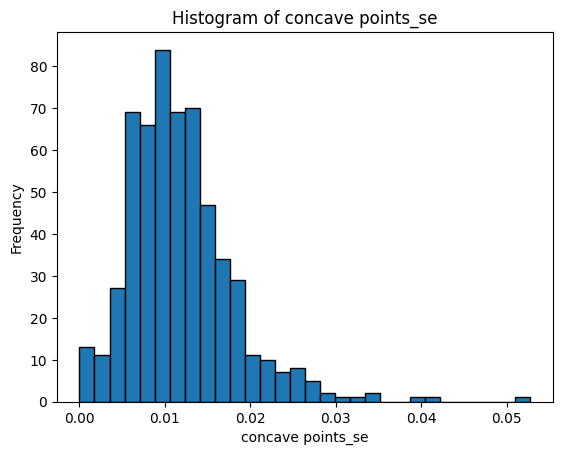

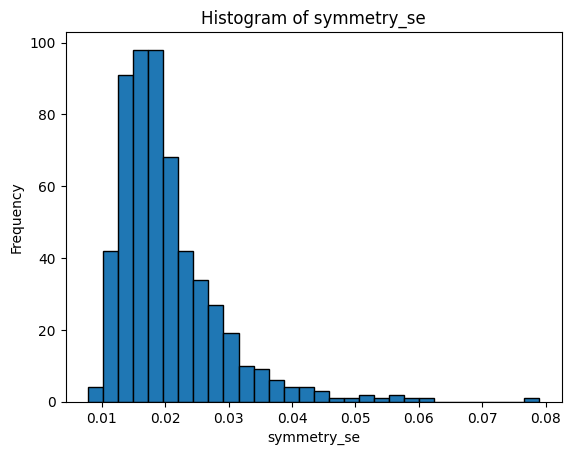

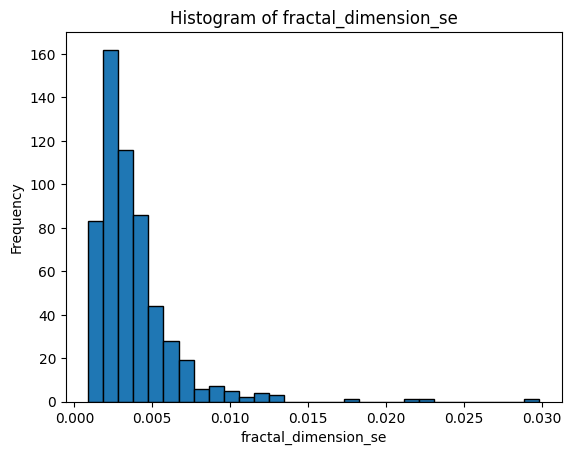

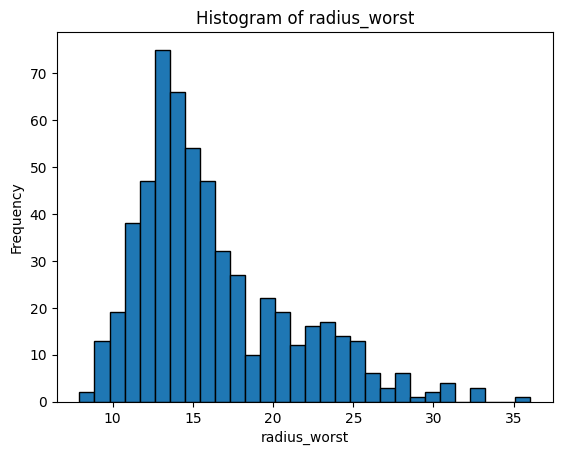

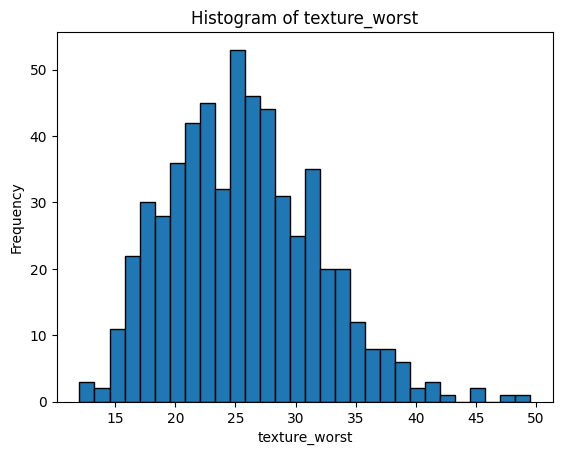

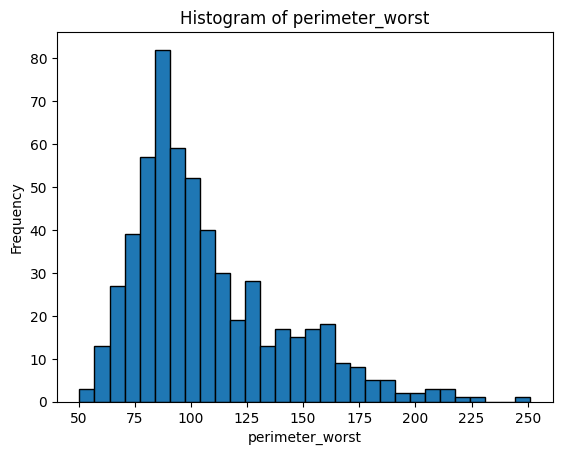

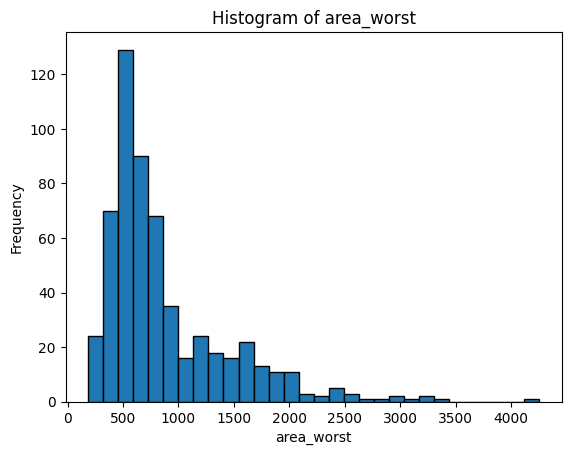

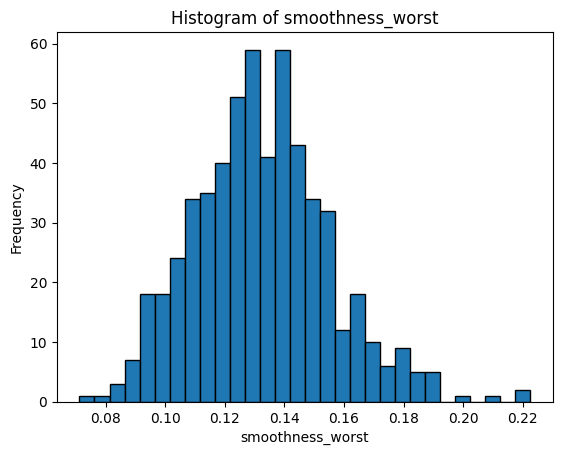

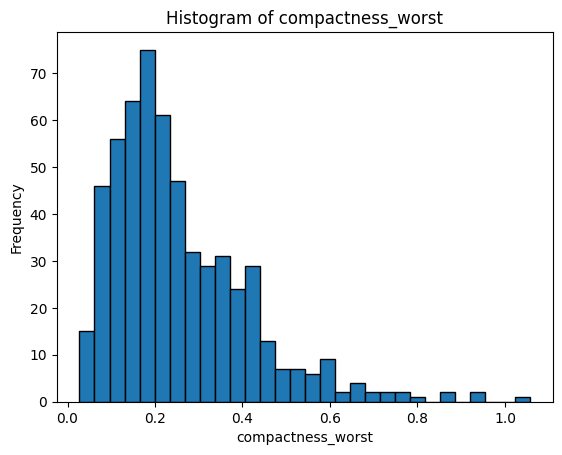

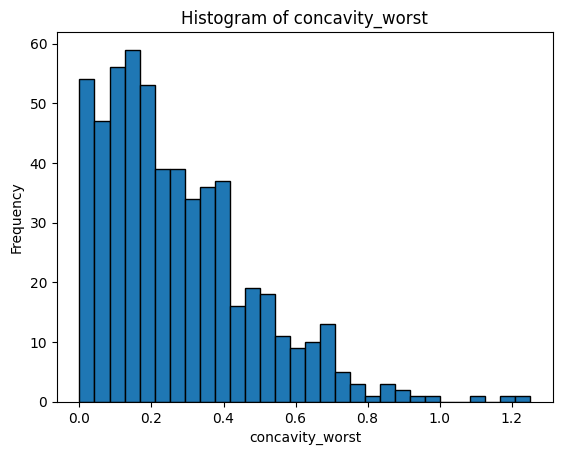

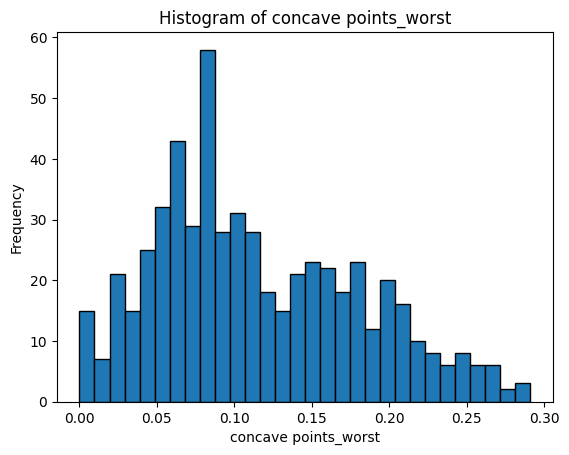

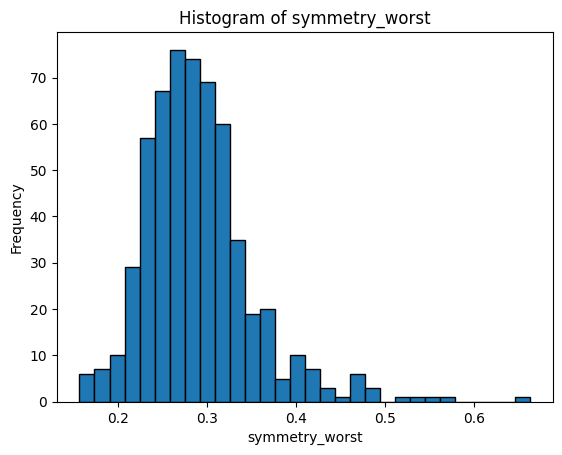

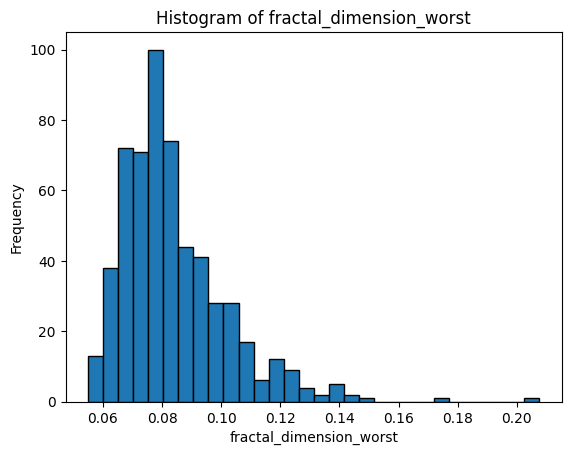

In [3]:
import matplotlib.pyplot as plt


continuous_columns = ["radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
                "compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean",
                "radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se",
                "concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst",
                "perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst",
                "concave points_worst","symmetry_worst","fractal_dimension_worst"]

discrete_columns = ["diagnosis"]

for discrete_column in discrete_columns:
    df[discrete_column].value_counts().sort_index().plot(kind="bar", title=f"Distribution of {discrete_column}")
    plt.xlabel(discrete_column)
    plt.ylabel("Count")
    plt.show()

for continuous_column in continuous_columns:
    plt.hist(df[continuous_column], bins=30, edgecolor='black')
    plt.title(f"Histogram of {continuous_column}")
    plt.xlabel(continuous_column)
    plt.ylabel("Frequency")
    plt.show()

At the moment, no missingness is visible at any feature plot.

### 4. Current missing-rate plot

To better visualize the missingness of the current dataset, `plot_missing_rate()` can be used. 

C:\Users\Utiizador\Desktop\mestrado1\semestre1\IA_E_SOCIEDADE\individual_assignment\mechanism_viewer\mechanism_viewer\viewer_simple.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig_missing_rate.tight_layout()


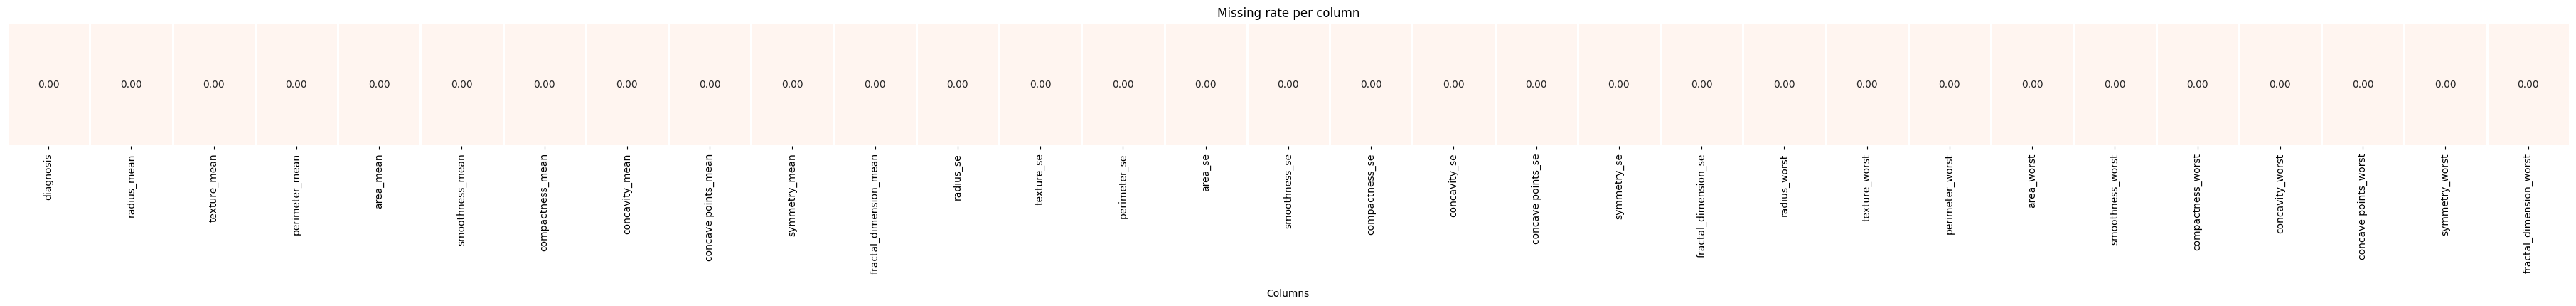

In [4]:
import mechanism_viewer as mv

_, _ = mv.plot_missing_rate(df, display_plot=True)

As expected, the dataset has no missing value.

### 5. Adding missingness to the features

To use the package for missingness pattern detection, the dataset is required to have some missingness

So, for the rest of the notebook uses a **controlled missingness copy** of the data. This is useful for testing whether the package functions behave correctly with this dataset's columns.

But first, it is important to convert the categorical column `diagnosis` into numeric, so that it can be used by the model-based and matrix tools.

In [5]:
df_temp = df.copy()
df_temp["diagnosis_num"] = df_temp["diagnosis"].map({"B": 0, "M": 1}).astype(int)
df_numeric = df_temp.drop(columns=["diagnosis"]).copy()

print("Current shape after numeric transformation:", df_numeric.shape)

Current shape after numeric transformation: (569, 31)


The next snippet of code keeps the original dataset unchanged and creates `missing_df`, a copy of the numeric dataset with missingness mechanisms applyed.

The injected mechanisms are the following:

- `smoothness_se`, `symmetry_se`, `fractal_dimension_se`, `texture_se`: applied with **MCAR**.
- `texture_mean`: applied with **MAR**. The removal is more often when observable features, such as, `diagnosis_num` and `area_mean` are high.
- `radius_worst`: applied with **MNAR**. The removal occurs more often based on its own high values.

> Note: This is only for demonstrating the package usability. It should not be reported as the real missingness of the uploaded dataset.

In [6]:
from mechanism_viewer import apply_mcar, apply_mar, apply_mnar, DEFAULT_RANDOM_STATE

missing_df = df_numeric.copy()

mcar_cols = ["smoothness_se", "symmetry_se", "fractal_dimension_se", "texture_se"]

for i,mcar_col in enumerate(mcar_cols):
    missing_df[mcar_col] = apply_mcar(missing_df[mcar_col], missing_rate=0.10, random_state=DEFAULT_RANDOM_STATE+i)

missing_df["texture_mean"] = apply_mar(missing_df["texture_mean"], 
                                        observable_df=missing_df[["diagnosis_num", "area_mean"]], 
                                        missing_rate=0.18, missingness_ascending=True)

missing_df["radius_worst"] = apply_mnar(missing_df["radius_worst"], missing_rate=0.15,
                                                missingness_ascending=True)

To confirm if the missingness mechanisms were applied, `plot_missing_rate()` can be used again:

C:\Users\Utiizador\Desktop\mestrado1\semestre1\IA_E_SOCIEDADE\individual_assignment\mechanism_viewer\mechanism_viewer\viewer_simple.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig_missing_rate.tight_layout()


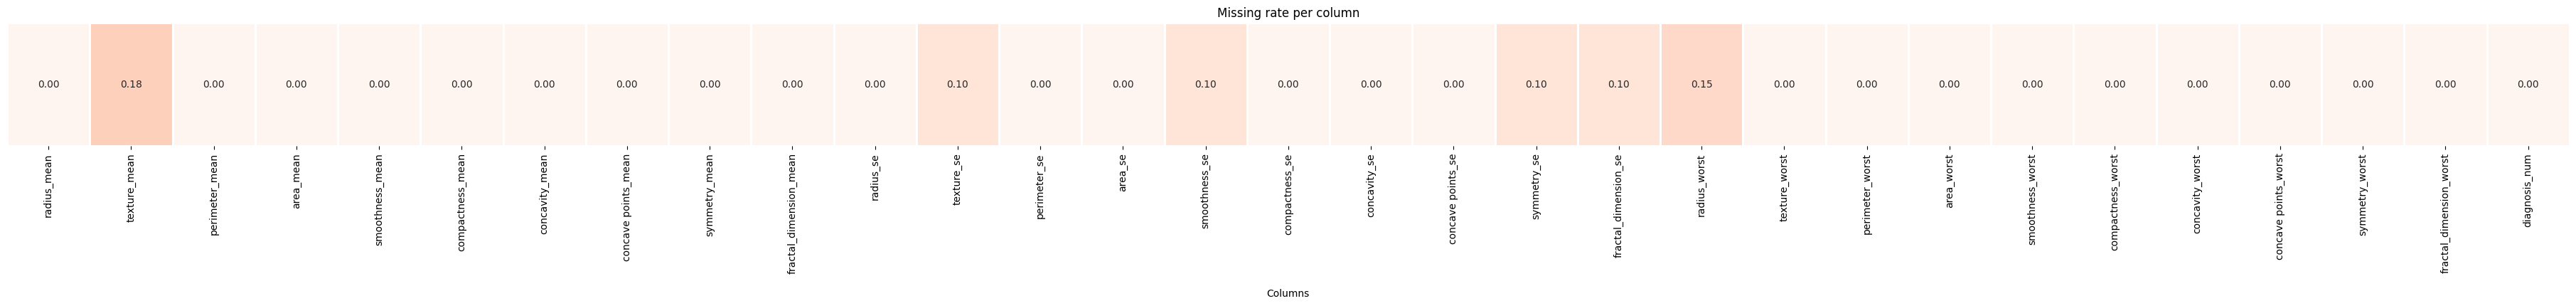

In [7]:
import mechanism_viewer as mv

_, _ = mv.plot_missing_rate(missing_df, display_plot=True)

As observable from the missing rate plot, the mechanisms were correctly applied. Thus, a missingness analysis can be done to the altered dataset.

> Note: The following sections will provide a missingness analysis, under the assumption that no prior information about the applied patterns is known.

### 6. Rows with similar missing-value patterns

The plot of `rows_with_similar_missing()` is similar to an UpSet-style summary. It shows which columns tend to be missing together in the same rows.

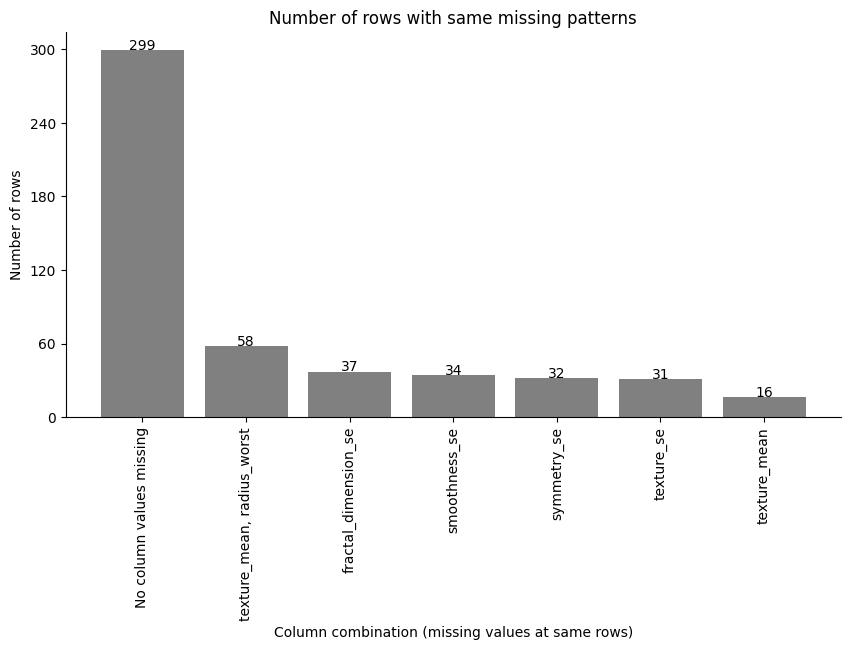

In [8]:
from mechanism_viewer import rows_with_similar_missing

fig, _ = rows_with_similar_missing(missing_df, min_rows_display=10)
display(fig)

Some rows have both `texture_mean` and `radius_worst` values missing. They occur with more frequency than the rows that have either `texture_mean` or `radius_worst` with missing values. Nevertheless, it could be due to similar missingness rate.

On the other hand, there is a considerable amount of rows with missing values on either `smoothness_se`, `symmetry_se`, `fractal_dimension_se` or `texture_se` column.

### 7. Missingness correlation heatmaps

To examine how the patterns relate to one another, multiple heatmaps can be used. The first plot will display the missingness correlation between all columns with missing values.

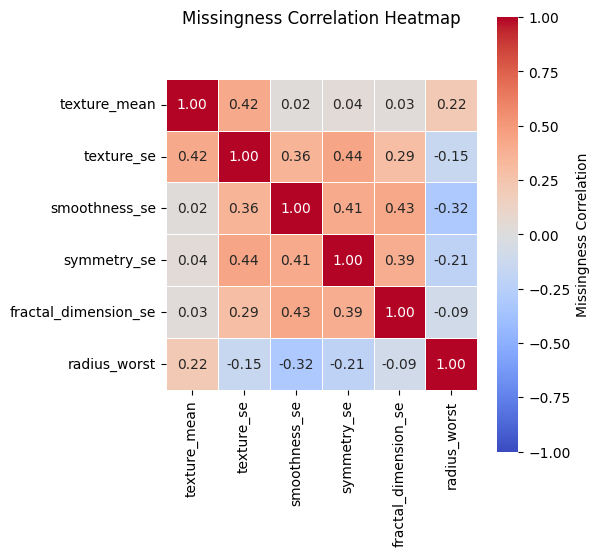

In [9]:
from mechanism_viewer import missing_columns_correlation, complete_and_missing_columns_correlation, missing_vs_all_correlation

_, _= missing_columns_correlation(missing_df, display_plot=True)

Several patterns emerge from the previous plot. First, ``texture_se``, ``smoothness_se``, ``symmetry_se``, and ``fractal_dimension_se`` show a moderate missingness relationship of about 0.4. In addition, ``texture_se`` has a similar correlation with ``texture_mean``, likely because both features stem from the same underlying measurement or procedure. However, the other ``_se`` features do not share this relationship with ``texture_mean``.

Another observation is that ``radius_worst`` has a slight positive association with ``texture_mean`` (0.22) but shows negative correlations with the remaining features. This suggests that the missingness pattern of ``radius_worst`` differs from the pattern shared by ``texture_se``, ``smoothness_se``, ``symmetry_se``, and ``fractal_dimension_se``.

More insight into the missingness patterns can be obtained using the function ``missing_vs_all_correlation()``, which plots the missigness of columns with the values of complete columns.

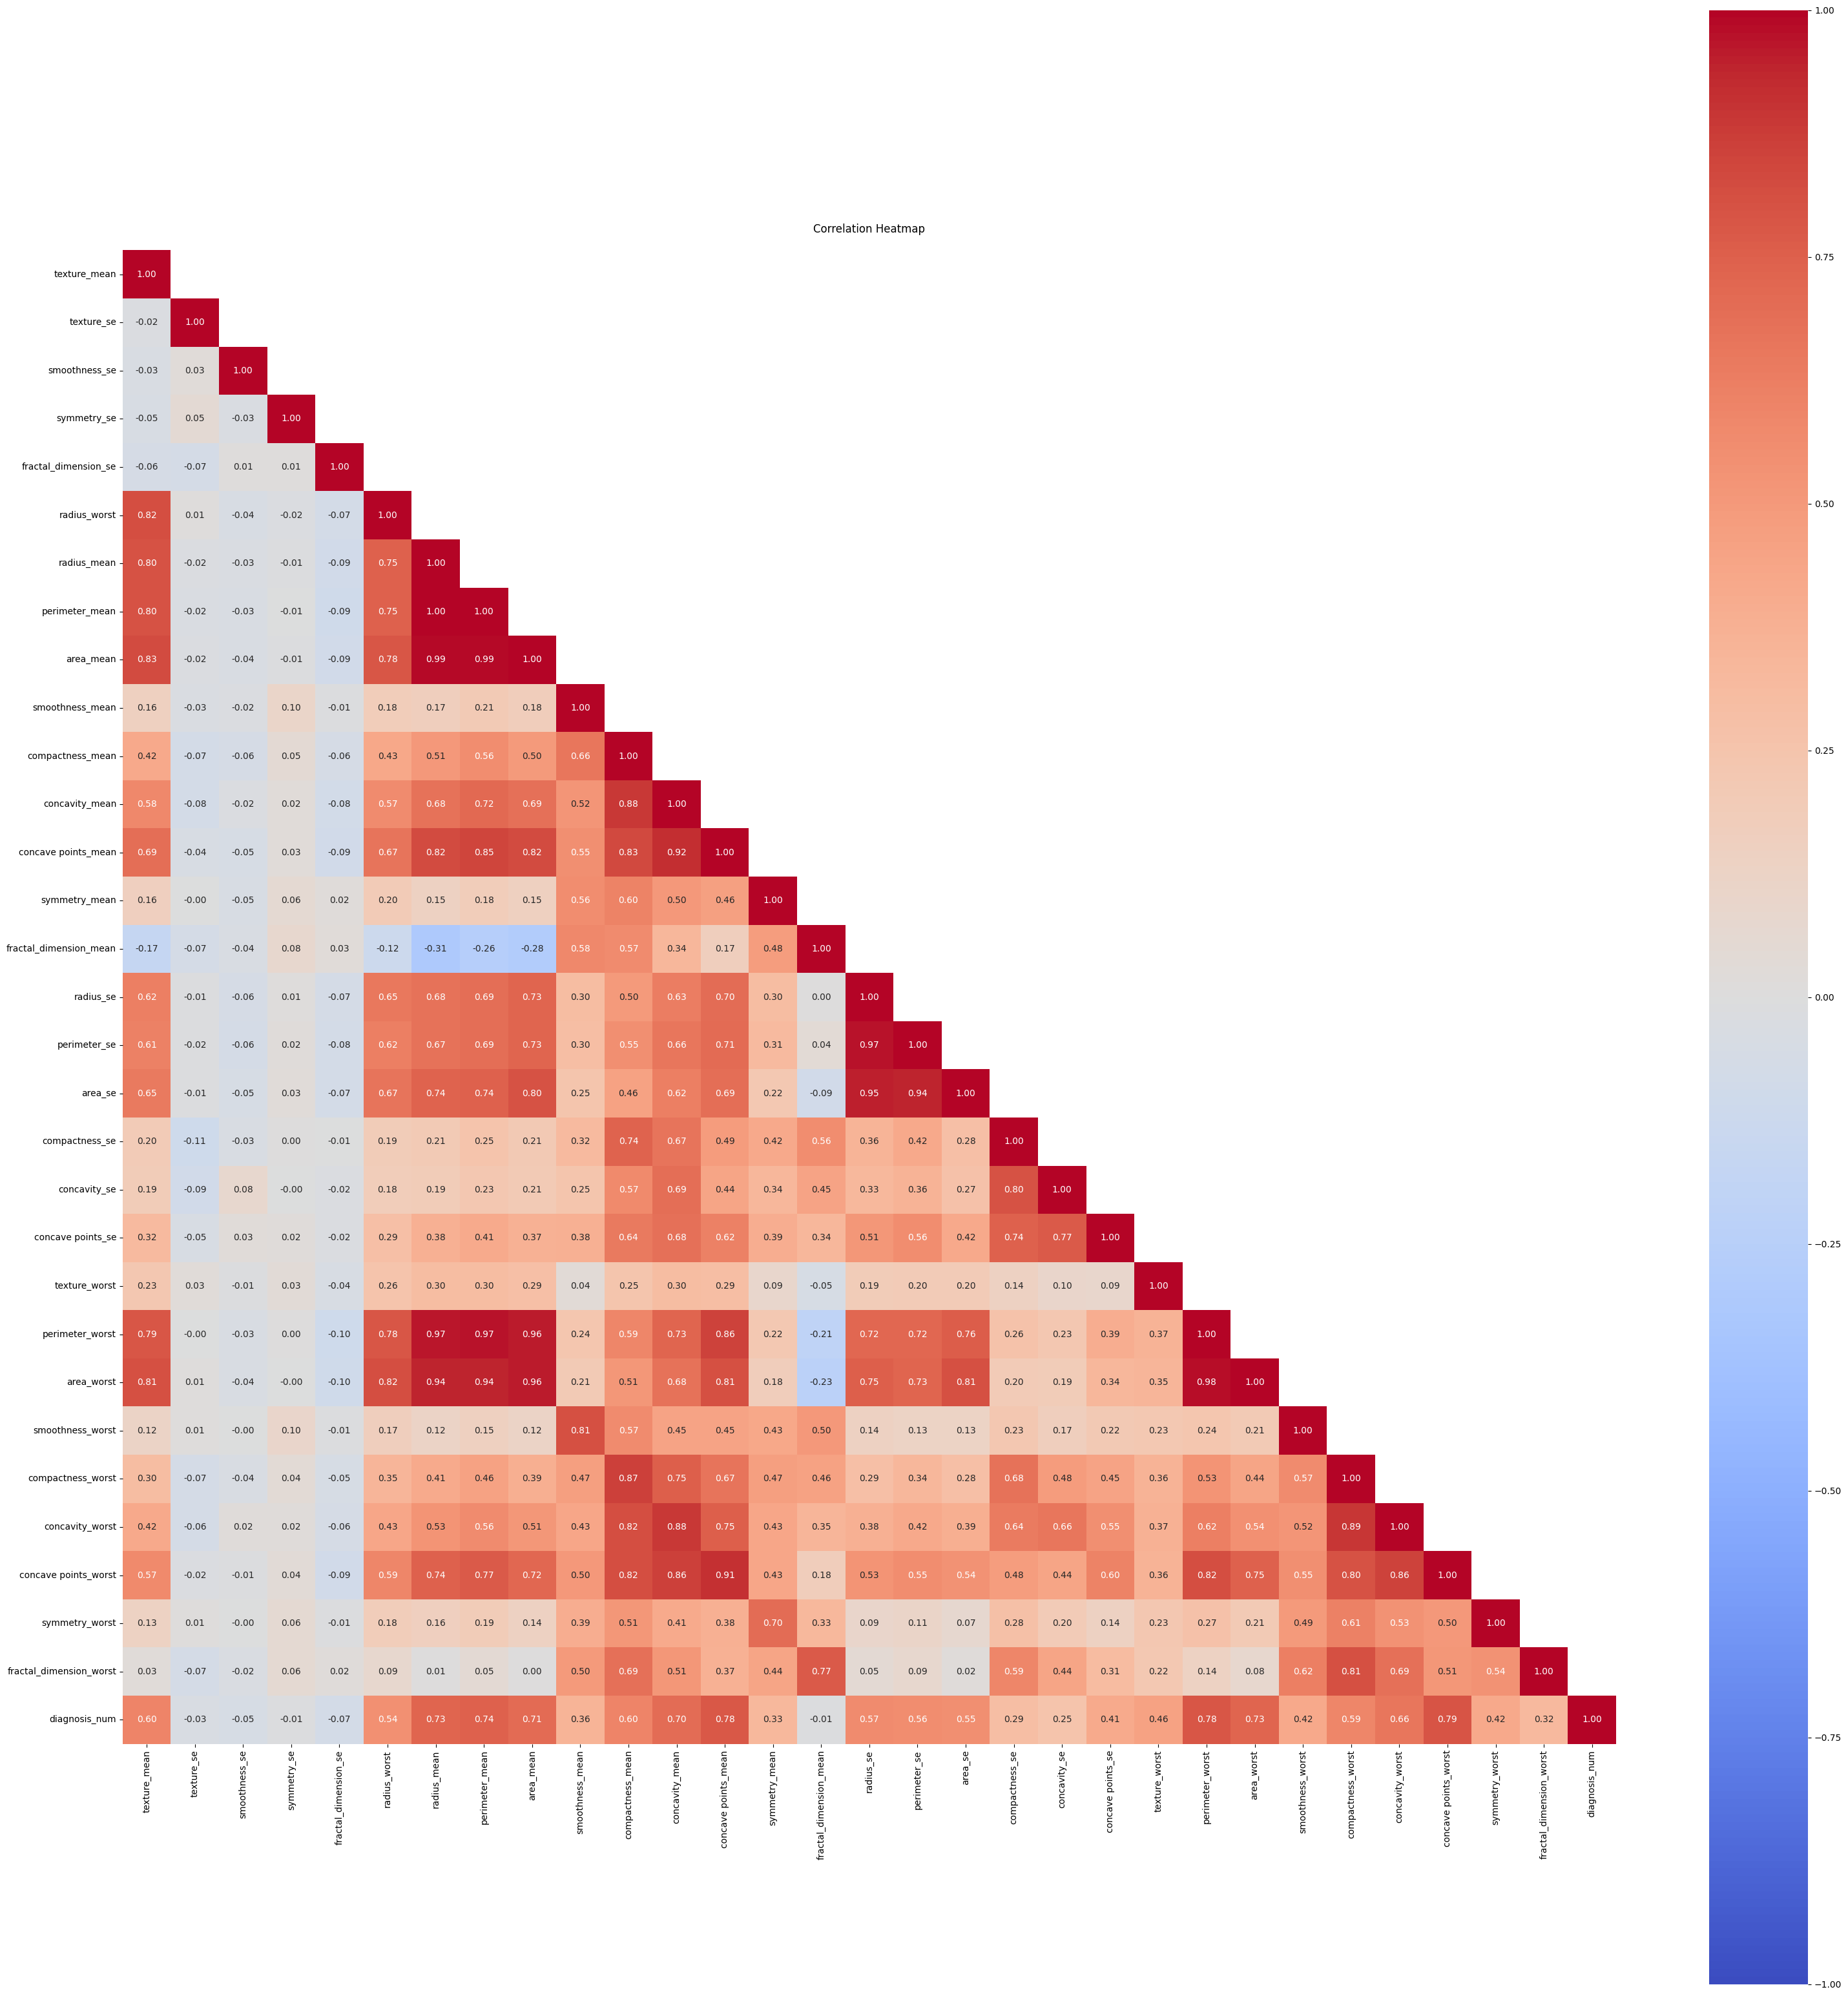

In [10]:
_, _ = complete_and_missing_columns_correlation(missing_df, display_plot=True)

From the heatmap, the features ``texture_se``, ``smoothness_se``, ``symmetry_se``, and ``fractal_dimension_se`` form a clear cluster with a distinct correlation pattern relative to the rest of the dataset. Since their missingness behaves similarly, and no other variable shows correlations that would indicate a dependency driving their missingness, this suggests that this group follows an ``MCAR`` missing‑data mechanism.

Because this dataset belongs to the health domain and contains many complete columns, it is unsurprising that numerous feature pairs exhibit medium to high correlations. Many variables are derived from the same underlying measurement process, which naturally produces strong associations. For instance, ``concave_points_mean`` and ``concavity_mean`` show a correlation of 0.92. Similarly, ``area_worst`` and ``perimeter_worst`` have an exceptionally high correlation of 0.98, which is mirrored in their nearly identical correlation profiles with other features. These two variables also correlate strongly (0.78–0.97) with ``radius_worst``, ``radius_mean``, ``perimeter_mean``, and ``area_mean``, likely because both area and perimeter are functions of radius.

One notable pattern is that ``radius_worst`` consistently shows the lowest correlations within this group when compared to ``radius_mean``, ``perimeter_mean``, and ``area_mean``. Since ``radius_worst`` is one of the variables with missing values, its reduced correlations may reflect the influence of its missingness mechanism.

Another feature with strong correlations to ``area_worst``, ``perimeter_worst``, ``radius_worst``, ``radius_mean``, ``perimeter_mean``, and ``area_mean`` is ``texture_mean``. Further testing is needed to determine whether this relationship arises from genuine measurement dependence or whether it reflects a ``MAR`` mechanism. This question becomes more intriguing because ``texture_worst`` does not share these correlations, neither with radius features nor with ``texture_mean``, which is unexpected.

Other variables may help explain the missingness behavior of ``texture_mean``, including ``diagnosis_num`` (0.60), ``concave_points_worst`` (0.57), ``radius_se``, ``perimeter_se``, ``area_se`` (0.61–0.65), ``concavity_mean`` (0.58), and ``concave_points_mean`` (0.69). However, these features also show similar correlation structures with the features related to radius, again with ``radius_worst`` consistently exhibiting lower values.

Actually, the values of ``radius_worst`` and ``texture_mean`` are very similar, to the point that maybe their missing data mechanism being the same, which that might be the reason the missingness of ``texture_mean`` has high correlation with the missingness of ``radius_worst``.

### 8. Global MCAR test

To quickly verify the existance of a non-MCAR mechanism in `texture_mean` or `radius_worst`, a global test using `little_mcar_test()` can be done. For the test, only the features that showed evidence of contributing to the generation of missingness dependencies in the missing columns will be selected.

In [11]:
columns_to_check = ["texture_mean", "radius_worst", "area_worst", "perimeter_worst", 
                    "radius_mean", "perimeter_mean", "area_mean", "diagnosis_num", "concave points_worst",
                     "radius_se", "perimeter_se", "area_se", "concavity_mean", "concave points_mean" ]

p_value = mv.little_mcar_test(missing_df[columns_to_check])
print(mv.interpret_mcar_p_value(p_value))


Obtained p_value is 0.0.

Interpretation: Reject the null hypothesis. Data is not MCAR (likely MAR or MNAR)


Even after filtering the dataset, the test indicates that at least one of the two missing features does not follow a MCAR mechanism, and instead is likely to have MAR or MNAR.

A similar test can be done using the previous observed columns and the `_se` features that showed similar pattern. 

In [12]:
columns_to_check_se = ["texture_se", "smoothness_se", "symmetry_se", "fractal_dimension_se",
                    "area_worst", "perimeter_worst", "radius_mean", "perimeter_mean",
                    "area_mean", "diagnosis_num", "concave points_worst", "radius_se",
                    "perimeter_se", "area_se", "concavity_mean", "concave points_mean" ]

p_value = mv.little_mcar_test(missing_df[columns_to_check_se])
print(mv.interpret_mcar_p_value(p_value))


Obtained p_value is 0.9935.

Interpretation: Fail to reject the null hypothesis. Data is likely MCAR


In contrast, the results suggest that this group of variables is most likely having MCAR mechnanism applied, which confirms the previous statements.

### 9. Simple Correlation Heatmap

To investigate whether the missingness of ``texture_mean`` and ``radius_worst`` is caused from the same non-MCAR mechanism, and to assess whether the patterns observed in the earlier heatmaps remain valid, it is necessary to reconsider how those heatmaps were constructed.

The previous visualizations computed correlations using missingness indicators rather than the actual feature values. As a result, pairs of missing columns were correlated based on their missingness patterns, while complete columns contributed correlations based on their observed values. This mixture made high correlations difficult to interpret, since the heatmaps did not directly reveal which features were influencing the missingness.

A fast way to determine whether the high correlations come from a true MAR mechanism or simply because the features are derived from the same measurement is to plot a simple heatmap. The most common correlation heatmap focus on making correlations based on the non-missing values of each feature, which  allows for direct comparison between variables.

It is also possible to include ``texture_worst`` on the plotting to check whether the previous behavior still holds, and to see whether ``texture_mean`` actually shows the same behavior when only the data correlations are examined.

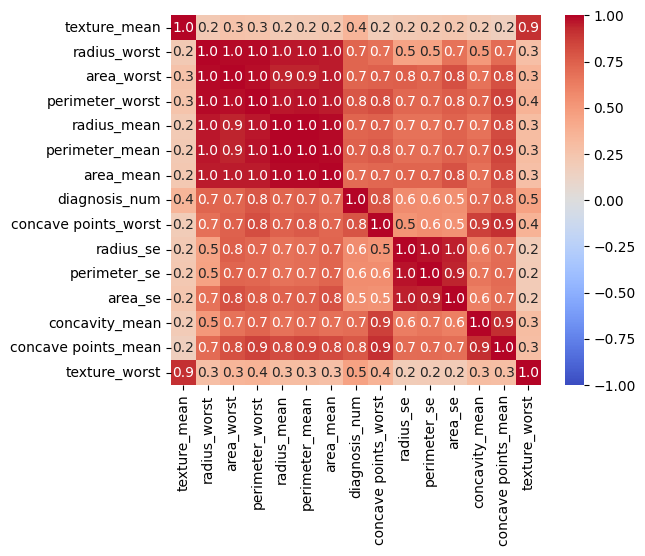

In [13]:
import seaborn as sns
import numpy as np

correlation_matrix = missing_df[columns_to_check + ["texture_worst"]].corr()

_ = sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap="coolwarm", vmin=-1, vmax=1, square=True)

The heatmap reveals a crucial pattern about the behavior of ``texture_mean``. While the previous heatmap suggested a strong correlation between the missingness of ``texture_mean`` and several observable variables, this heatmap shows that the actual values of ``texture_mean`` are not correlated with those same features. Futhermore, the correlation between ``texture_worst`` and ``texture_mean`` finally presents itself with a very high value, which is expected since both measurements capture the same attribute.

For the missingness of ``texture_mean`` to almost remove its original correlation structure and create strong missingness correlations with features that originally had little direct relationship with ``texture_mean``, the applied missingness mechanism is most likely MAR. This is because the missingness pattern appears to be driven by other observed variables rather than by ``texture_mean`` itself. In contrast, MCAR would not be expected to create such strong structured associations, and MNAR would mainly depend on the values of ``texture_mean``, not on unrelated observed columns.

Meanwhile, the value correlation present in `radius_worst` is the oposite of ``texture_mean``. The column `radius_worst` displays a strong value correlation with the expected observable variables, mainly `area_worst`, `perimeter_worst`, `radius_mean`, `area_mean`, and `perimeter_mean`. This indicates that while the missingness of ``texture_mean`` completely changes the behaviour of ``texture_mean``, the missingness of `radius_worst` simply attenuates the existing correlations between the observable features. One thing is certain: if ``radius_worst`` had the same missingness pattern applied as ``texture_mean``, the missingness correlations would most likely increase, and not decrease.

As observed before, the other missing columns, ``texture_se``, ``smoothness_se``, ``symmetry_se``, and ``fractal_dimension_se``, which are likely to have MCAR applied, show missingness patterns that largely remove any clear correlation with the observable variables. Thus, it can be cautiously suggested that because ``radius_worst`` does not show a pattern similar to the proposed MCAR-applied features, nor to the possible MAR column ``texture_mean``, it is likely that ``radius_worst`` follows an MNAR missing-data mechanism. Of course, providing additional evidence for MNAR is highly difficult, because the package tools are mainly designed to identify dependencies on observable features. And since ``radius_worst`` still maintains relatively strong correlations with the observable features, using these tools alone could most likely mislead us into interpreting its missingness pattern as MAR.

### 10. Imputation for MNAR detection

As stated above, using observable variables to infer the missing‑data mechanism for ``radius_worst`` is challenging, largely because this feature is highly correlated with several others. For example, when ``area_mean`` is used as the x‑axis in the plot generated by ``scatterplot_imputation_comparison()``, the imputed values for both ``radius_worst`` and ``texture_mean`` appear predominantly on the right side of the plot, that is, at higher values of ``area_mean``. This would imply that both variables may follow a MAR mechanism. In contrast, one of the features likely to follow MCAR, ``texture_se``, shows imputed values dispersed along the full range of ``area_mean``, reinforcing the conclusion that its missingness is consistent with an MCAR pattern.

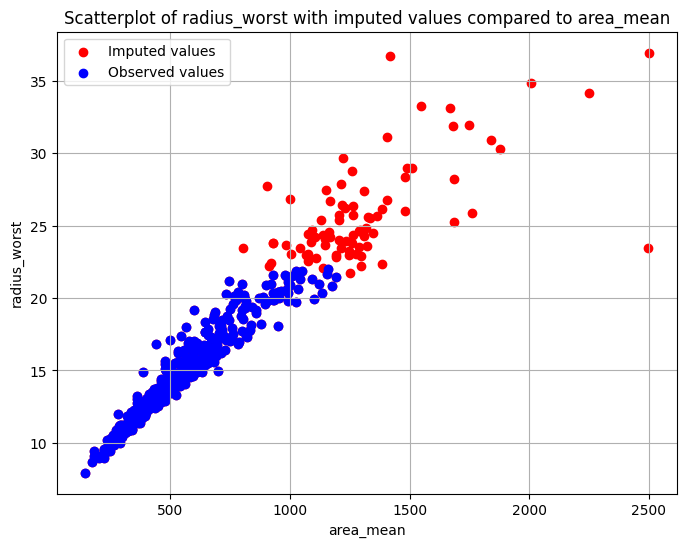

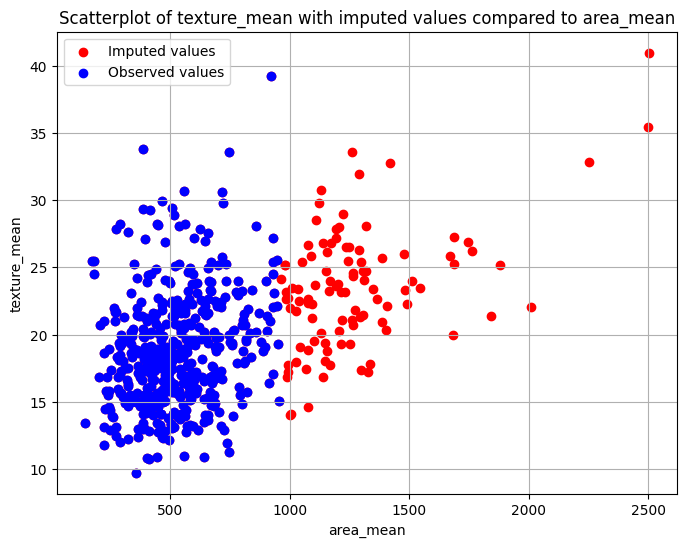

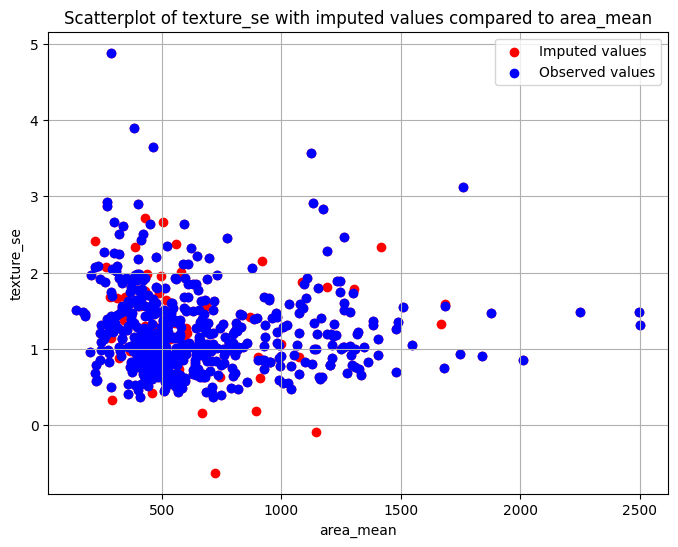

In [14]:
from mechanism_viewer import ColType

_, _ = mv.scatterplot_imputation_comparison(missing_df, column_name="area_mean", missing_col="radius_worst", missing_col_type=ColType.CONTINUOUS, display_plot=True)

_, _ = mv.scatterplot_imputation_comparison(missing_df, column_name="area_mean", missing_col="texture_mean", missing_col_type=ColType.CONTINUOUS, display_plot=True)

_, _ = mv.scatterplot_imputation_comparison(missing_df, column_name="area_mean", missing_col="texture_se", missing_col_type=ColType.CONTINUOUS, display_plot=True)

However, when the missing feature itself is used as the x‑axis, the patterns in the scatterplots change substantially. Both ``texture_se`` and ``texture_mean`` show imputed values scattered along the diagonal line created. That being said, ``radius_worst`` displays a distinctly different structure: the diagonal line separates into two colors, with observed values concentrated at the lower end and imputed values appearing at the higher end. This striking pattern may suggest that missingness in ``radius_worst`` affects its higher values.

It is important to emphasize that the imputation process is still the same: the model continues to use the complete columns to estimate the missing values. The only modification is the choice of x‑axis, yet this alone reveals a markedly different distributional pattern.

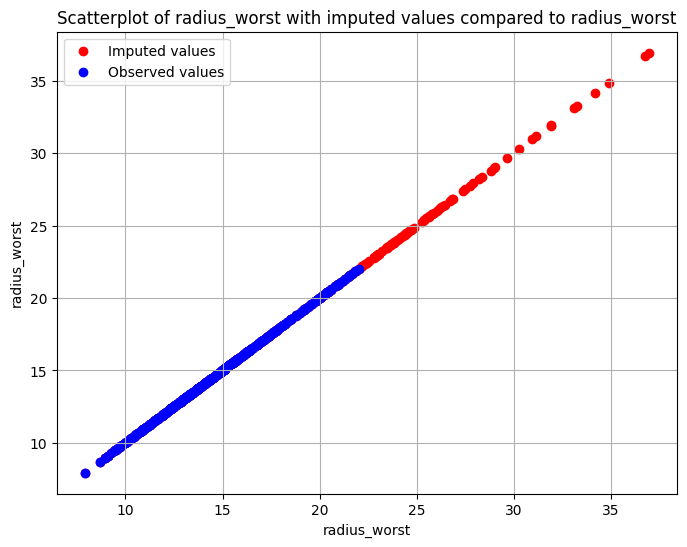

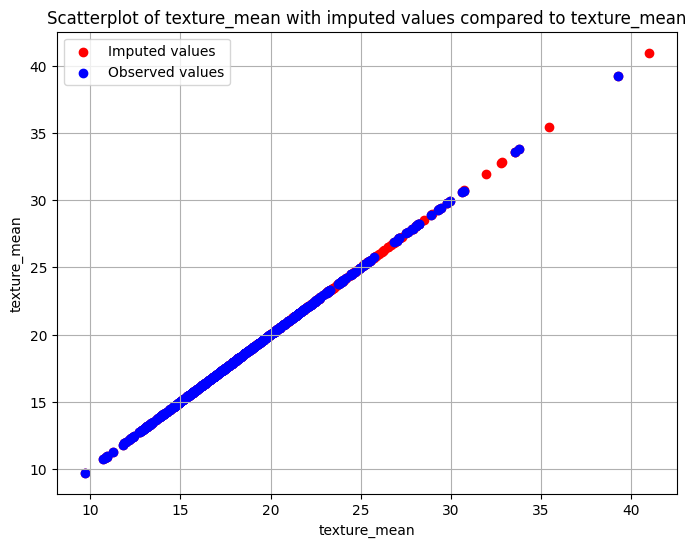

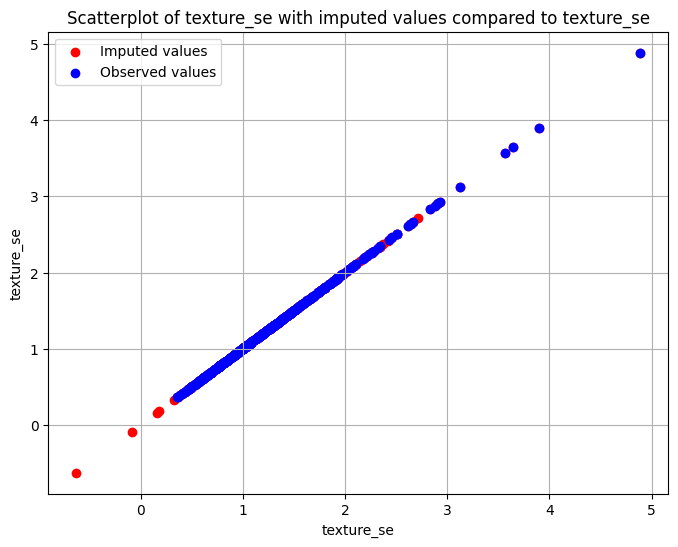

In [15]:
_, _ = mv.scatterplot_imputation_comparison(missing_df, column_name="radius_worst", missing_col="radius_worst", missing_col_type=ColType.CONTINUOUS, display_plot=True)

_, _ = mv.scatterplot_imputation_comparison(missing_df, column_name="texture_mean", missing_col="texture_mean", missing_col_type=ColType.CONTINUOUS, display_plot=True)

_, _ = mv.scatterplot_imputation_comparison(missing_df, column_name="texture_se", missing_col="texture_se", missing_col_type=ColType.CONTINUOUS, display_plot=True)

This observation provides additional evidence that ``radius_worst`` may follow a different missing‑data mechanism compared to ``texture_mean``, since both features exhibit different behaviors when visualized in this manner.

### 11. Missingness dependency of `texture_mean`

As it was established that the missingness of ``texture_mean`` appears to drive its high missing correlations with multiple variables, suggesting the feature is most likely MAR, the next step is to identify which variables most strongly influence this pattern. This can be done with ``visualize_column_dependencies()``.

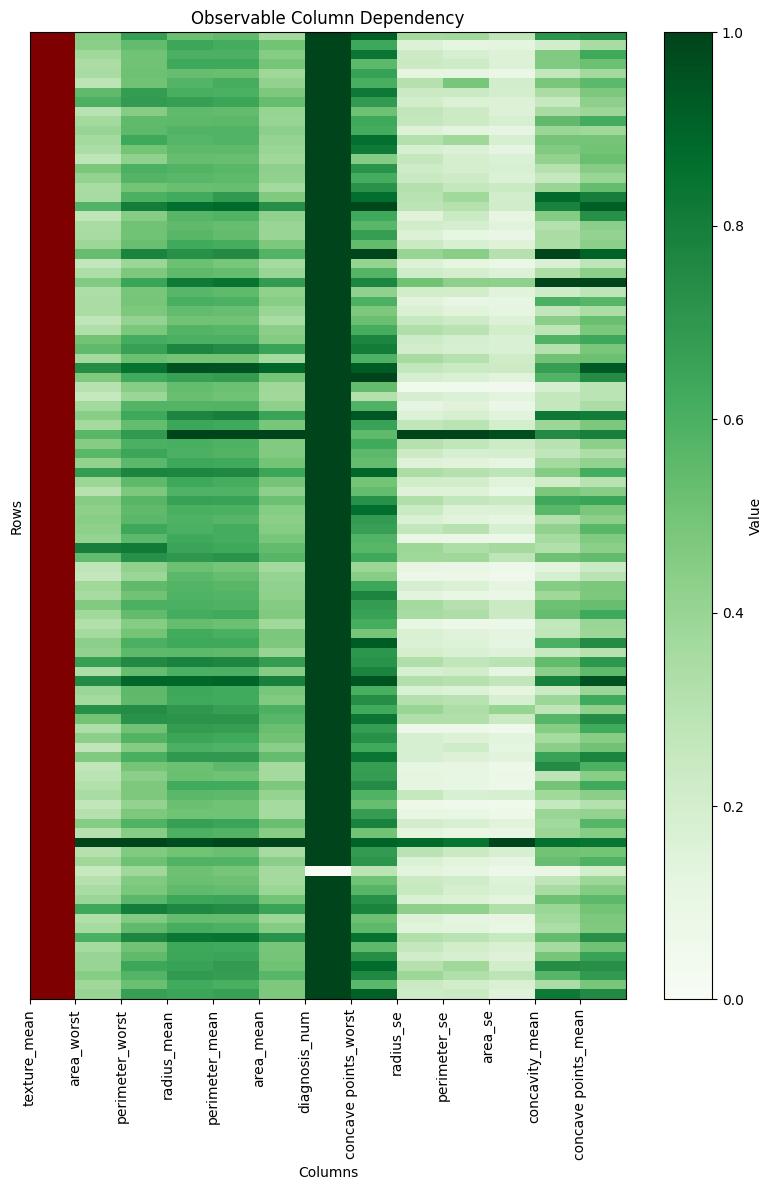

In [16]:
columns_tex_mean = ["texture_mean", "area_worst", "perimeter_worst", "radius_mean", 
                    "perimeter_mean", "area_mean", "diagnosis_num", "concave points_worst",
                    "radius_se", "perimeter_se", "area_se", "concavity_mean", "concave points_mean" ]

_ = mv.visualize_column_dependencies(missing_df[columns_tex_mean], display_plot=True)

The column ``diagnosis_num`` has most of its values as high when ``texture_mean`` is missing. Therefore, it is likely that ``diagnosis_num`` is an observable column that may affect the existence of missing values in ``texture_mean``. Knowing that ``diagnosis_num`` is the numerical encoding of ``diagnosis``, where "B" is encoded as 0 and "M" as 1, it can be inferred that texture_mean missingness is more prevalent when the cancer diagnosis is Malignant (M).

For other features its harder to infer by only observing this plot, although ``radius_se``, ``perimeter_se`` and `area_se` have generally low values.

### 12. Further exploration with `boxplot_comparison()`

A more detail approach can be done by examining the distribution of each observable feature in scenarios where `texture_mean` is missing and not missing.

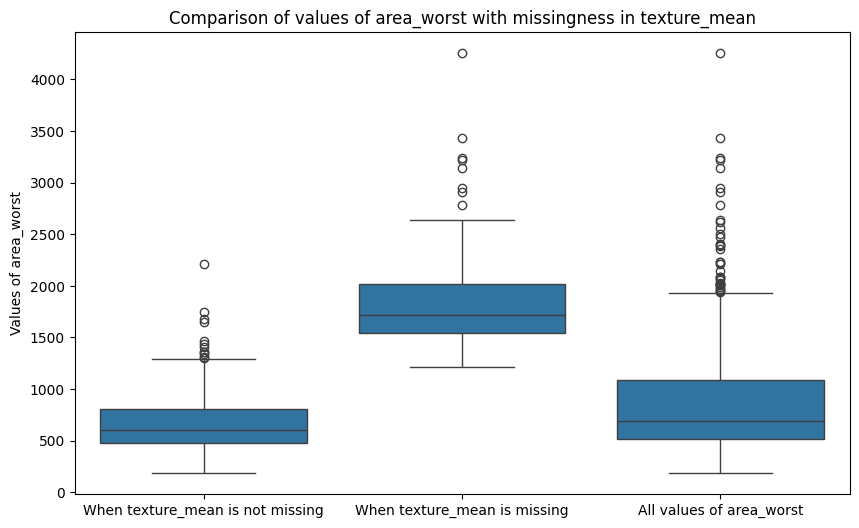

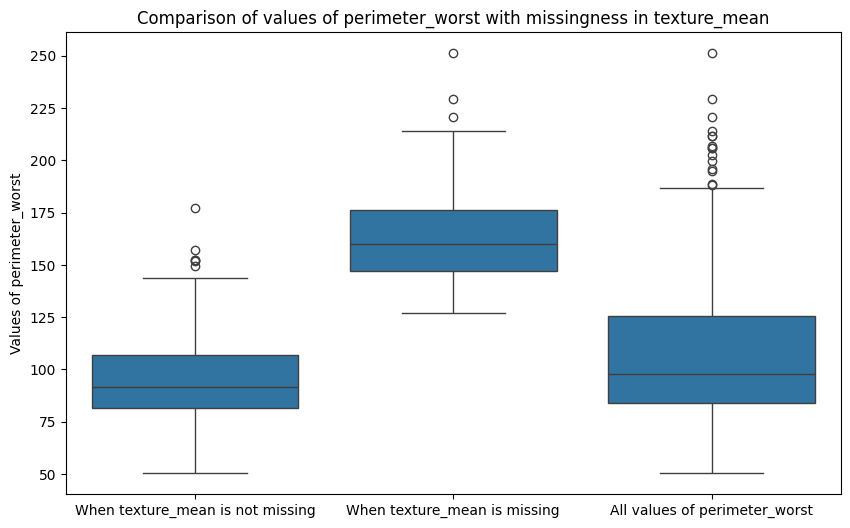

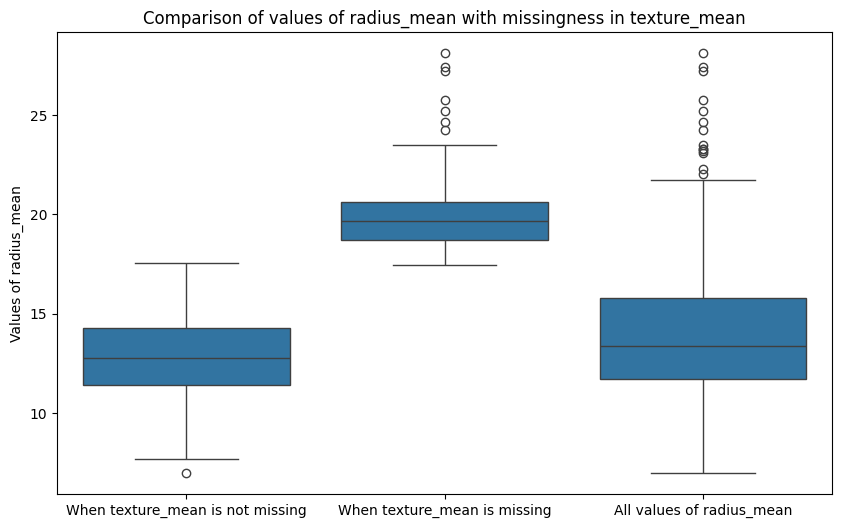

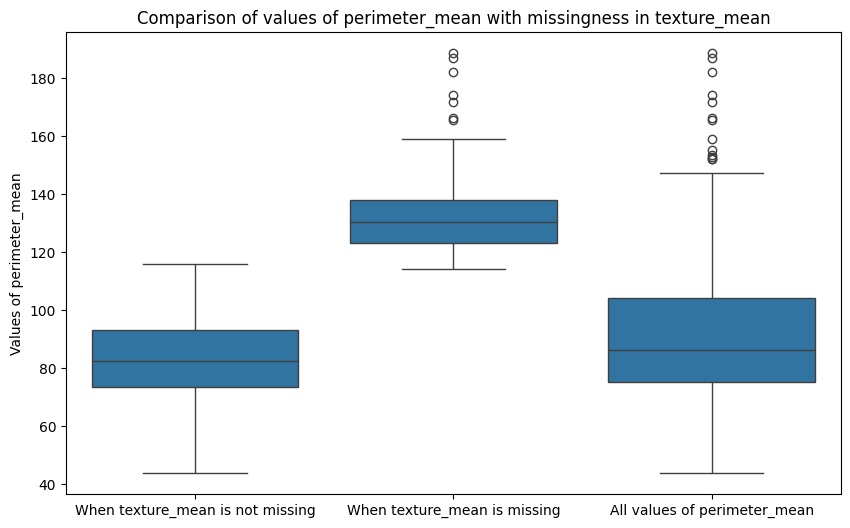

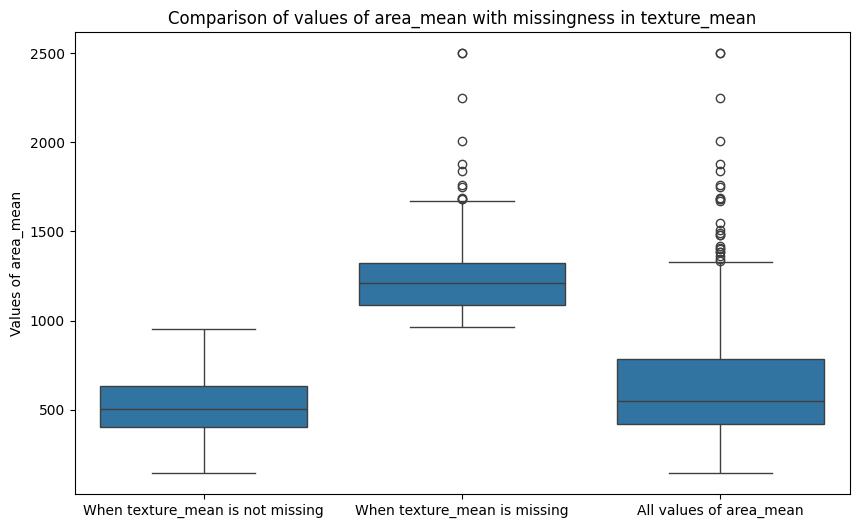

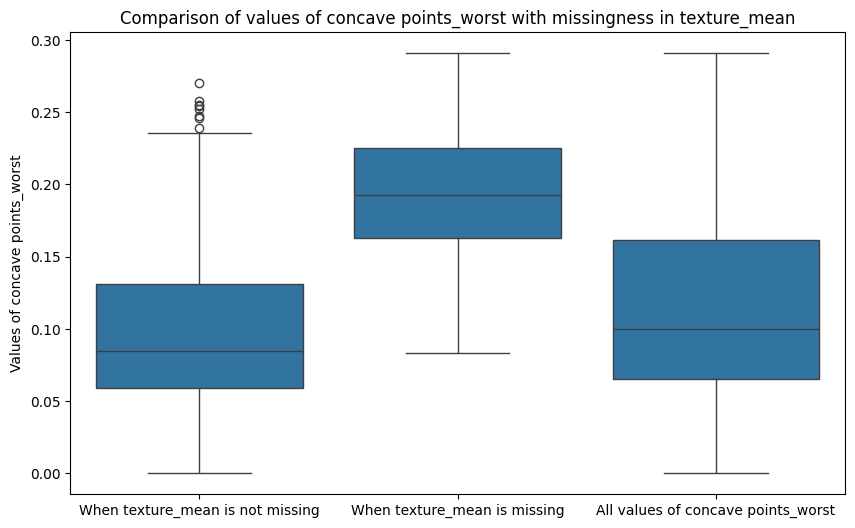

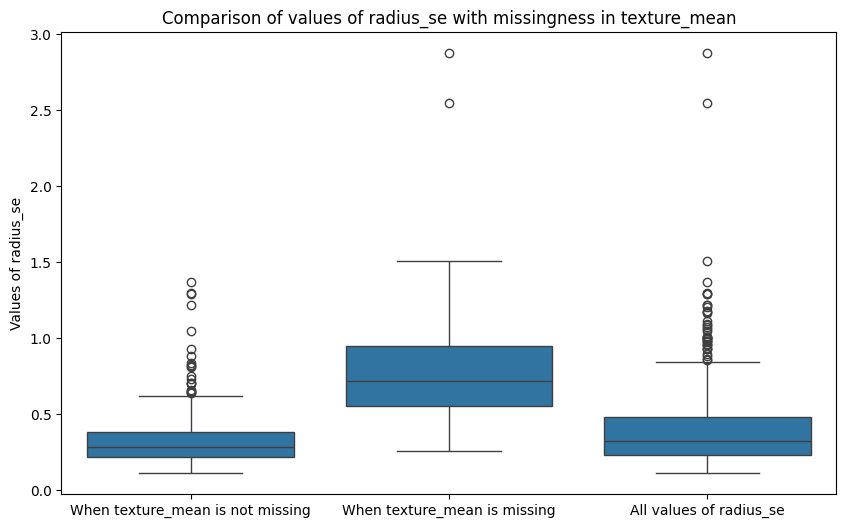

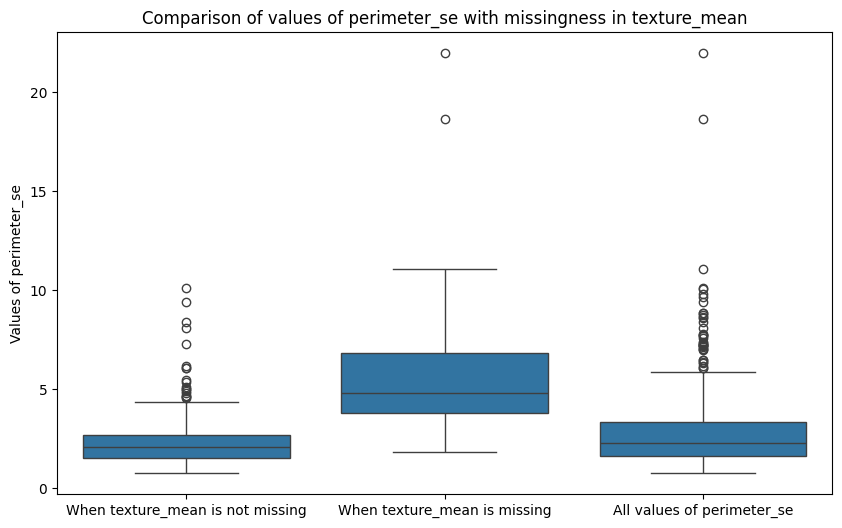

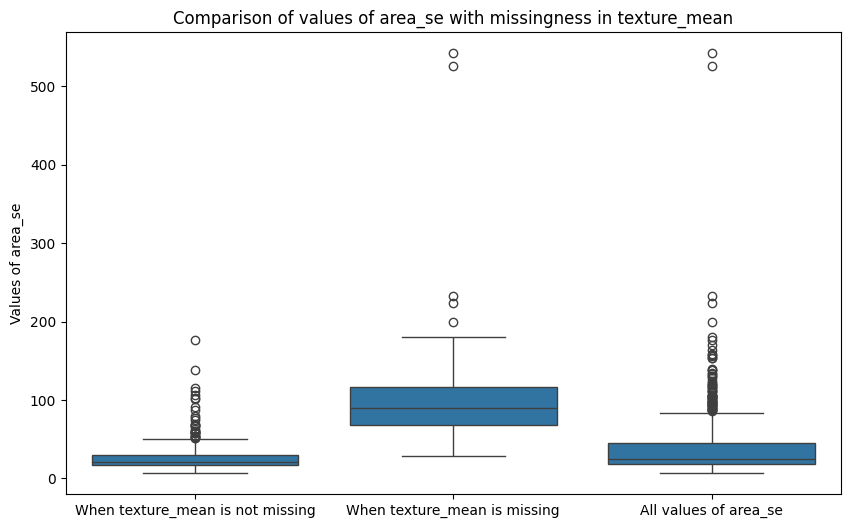

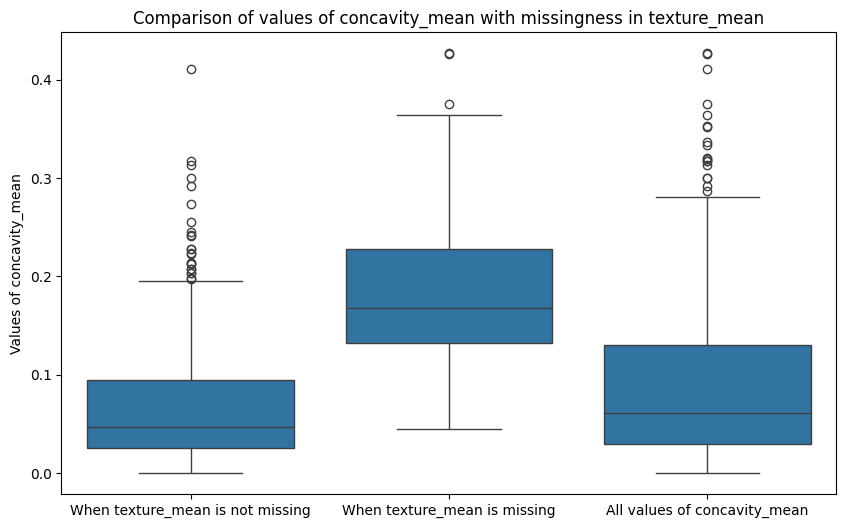

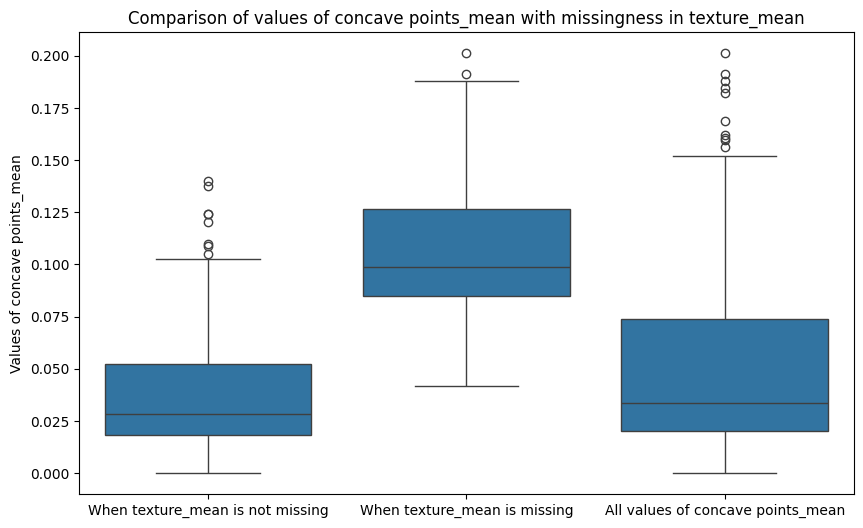

In [18]:
for observable_col in columns_tex_mean:
    if observable_col not in ["texture_mean", "diagnosis_num"]:
        _, _ = mv.boxplot_comparison(missing_df, column_name=observable_col, missing_col="texture_mean", display_plot=True)

Across almost every observed feature, the group where ``texture_mean`` is missing has much higher values than the group where ``texture_mean`` is not missing. This is especially clear for ``area_mean``, ``radius_mean``, ``perimeter_mean``, ``area_worst``,  and ``perimeter_worst``.

This indicates that the missingness of ``texture_mean`` is not random. Instead, the missing values are concentrated in a specific subset of observations with larger and more irregular tumour features. And because this pattern is explainable using observed variables, it supports a MAR missingness mechanism.

Obviously, as many of these observed features are strongly correlated with each other, the boxplots should be interpreted as evidence of a non random missingness, and not as proof that every individual feature directly caused the missingness.

### 13. Summary of missingness pattern identification

After analysing the encoded dataset with missing-data mechanisms applied to selected columns, several conclusions can be drawn.

The strongest conclusions are as follows:

- `texture_se`, `smoothness_se`, `symmetry_se`, and `fractal_dimension_se` show MCAR behaviour. Their missingness does not appear to be strongly affected by, correlated with, or associated with the observable features.

- `radius_worst` behaves differently from `texture_mean`. This is supported by the different correlation values obtained when comparing the observed values with the observable columns, even though the missingness correlation patterns may appear similar. In addition, the imputation plots show different behaviours when each feature is plotted against itself on the x-axis.

- Since the correlation structure of `radius_worst` only slightly decreases after introducing missingness, without creating strong new associations with other observable features, it is reasonable to interpret `radius_worst` as having an MNAR mechanism. This differs from the `_se` features, where the correlations are mostly removed, and from `texture_mean`, where several missingness correlations increase strongly.

- `texture_mean` resembles a feature with a MAR missing-data mechanism. Its behaviour changes sharply after missing values are introduced, and its missingness becomes strongly associated with features that were not previously strongly correlated with the observed `texture_mean` values. Although several features appear associated with the missingness of `texture_mean`, especially `area_mean`, `radius_mean`, `perimeter_mean`, `area_worst`, and `perimeter_worst`, it remains uncertain which specific feature is independently responsible for activating the missingness. However, `diagnosis_num` appears to be a strong indicator of `texture_mean` missingness, particularly when it corresponds to malignant tumours.



### 14. Final conclusion

Ultimately, most of the missing-pattern insights were identified correctly, especially the missing-data mechanism applied at each missing column. The only aspect that could not be proven was which specific feature generated the missingness of `texture_mean`.

In more detail, `diagnosis`, encoded as `diagnosis_num`, was correctly identified as variable used for the generation of missingness. However, because `area_mean` is highly correlated with multiple other features related to the size of the tumor, it is not possible to prove from the plots alone that `area_mean` specifically caused the missingness.